# Insurance Cost Prediction Analysis

### This project builds a machine learning regression system to predict the insurance charges billed to an individual based on provided factors like (like smoking), biology (age, BMI), and demographics (region, gender).The goal of the data analysis was to identify key factors influencing insurance costs and evaluate machine learning model performance.


In [237]:
import pandas as pd  #Importing Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [238]:
df=pd.read_csv(r'C:\Users\rohit\Desktop\Datamites Data\Insurance cost prediction\datasets_13720_18513_insurance(1).csv') # importing dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [239]:
df[df.duplicated()]  ## Checking duplicates

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [240]:
df.drop_duplicates(inplace=True) #removing duplicates

In [241]:
df.isnull().sum() #checking null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [242]:
df.info() # looking for null values, datatype

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [243]:
df.describe() # looking for numercal columns

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [244]:
df.describe(include=object) # looking for non-numercal columns

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [245]:
for col in df.describe().columns: #looking for unique values in each numerical columns
    print(col)
    print(df[col].unique())
    print ('-'*50)

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
--------------------------------------------------
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 2

In [246]:
for col in df.describe(include=object).columns: ##looking for unique values in each numerical columns
    print(col)
    print(df[col].unique())
    print('-'*50)

sex
['female' 'male']
--------------------------------------------------
smoker
['yes' 'no']
--------------------------------------------------
region
['southwest' 'southeast' 'northwest' 'northeast']
--------------------------------------------------


In [247]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<Axes: >

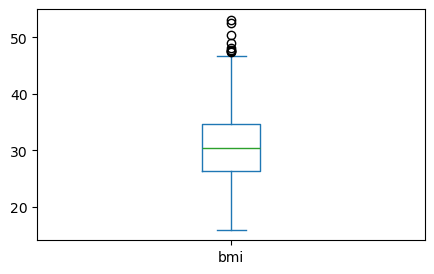

In [248]:
plt.figure(figsize=(5,3)) # visualizing and eliminating outlier
df['bmi'].plot(kind='box')

In [249]:
df=df[df['bmi']<50]

<Axes: xlabel='age', ylabel='charges'>

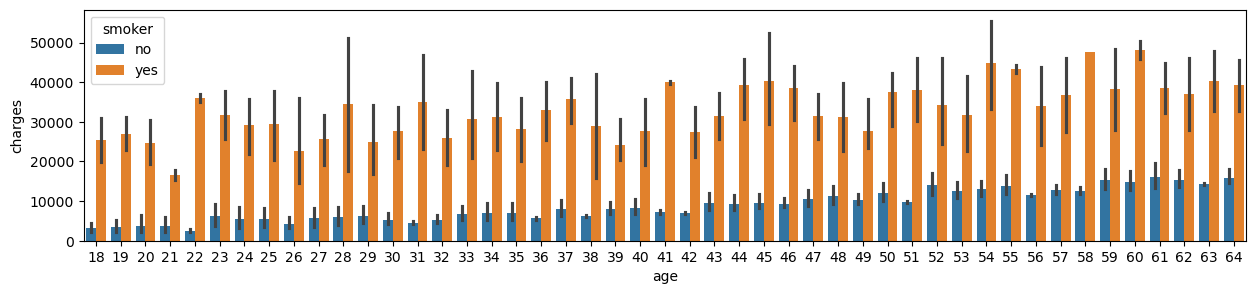

In [250]:
plt.figure(figsize=(15,3)) #visaualizing effect of smoking on charges which shows smoking lead to high charges also we can find that with age charges increases
sns.barplot(x='age',y='charges',data=df,hue='smoker')

<Axes: xlabel='age', ylabel='charges'>

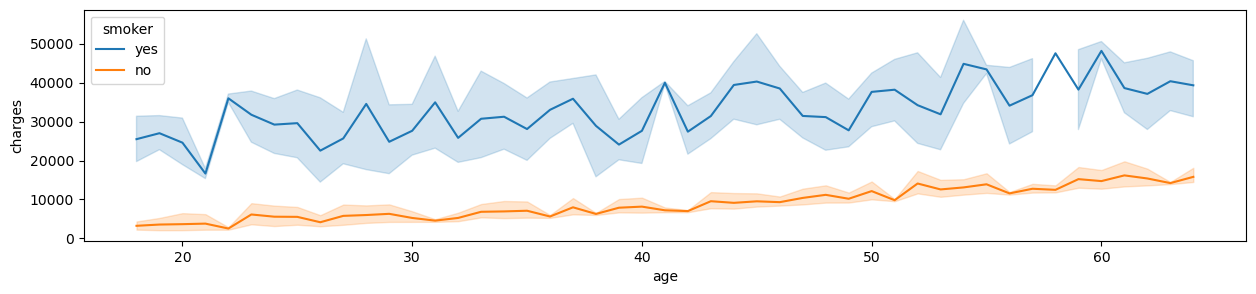

In [251]:
plt.figure(figsize=(15,3)) #visaualizing effect of smoking on charges which shows smoking lead to high charges
sns.lineplot(x='age',y='charges',data=df,hue='smoker')

<Axes: xlabel='age', ylabel='charges'>

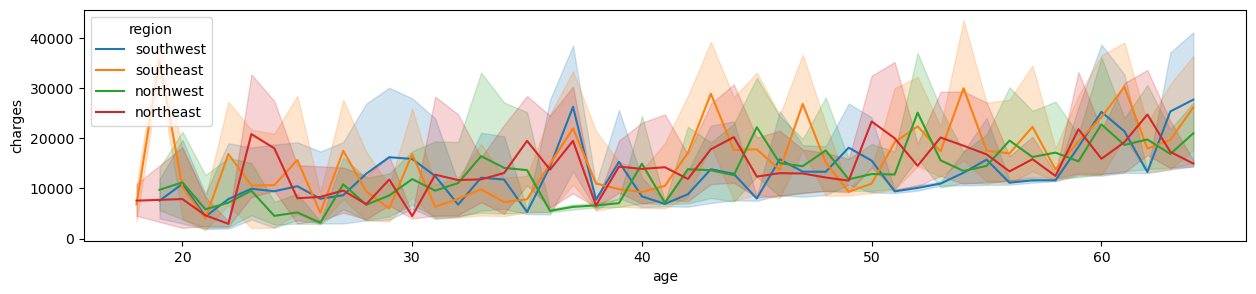

In [252]:
plt.figure(figsize=(15,3)) # visualizing effect of region on charges having similar effect on charges,hence this column is not decision maker.
sns.lineplot(x='age',y='charges',data=df,hue='region')

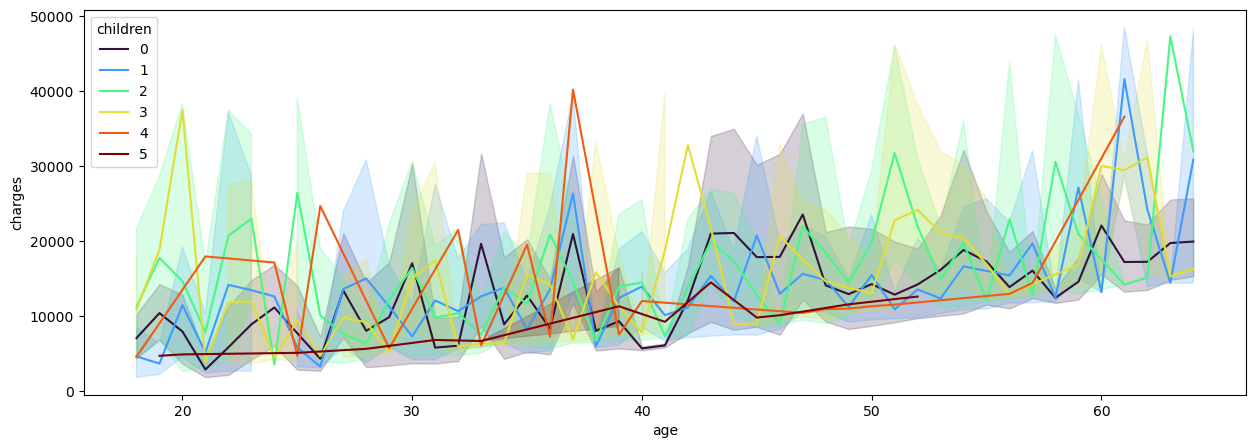

In [253]:
plt.figure(figsize=(15,5))  ## # visualizing effect of age on charges and find that premium increase drastically after age of 60, 

sns.lineplot(x='age',y='charges',data=df,hue='children',palette='turbo',legend="full")
plt.show()

<Axes: xlabel='age', ylabel='charges'>

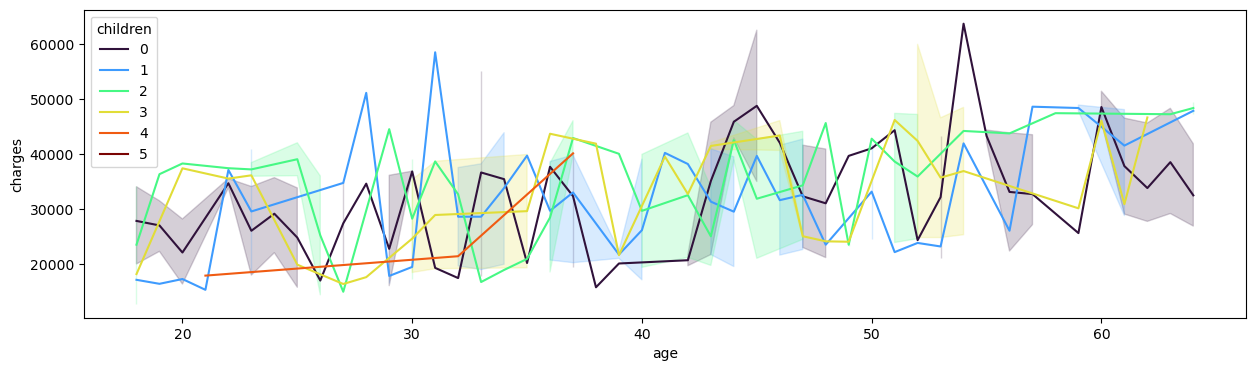

In [254]:

dfs=df[df['smoker']=='yes'] ## visualizing effect of children on charges for smoker and find that with increase in children charges unevenly increases.
plt.figure(figsize=(15,4)) 

sns.lineplot(x='age',y='charges',data=dfs,hue='children',palette='turbo')


<Axes: xlabel='age', ylabel='charges'>

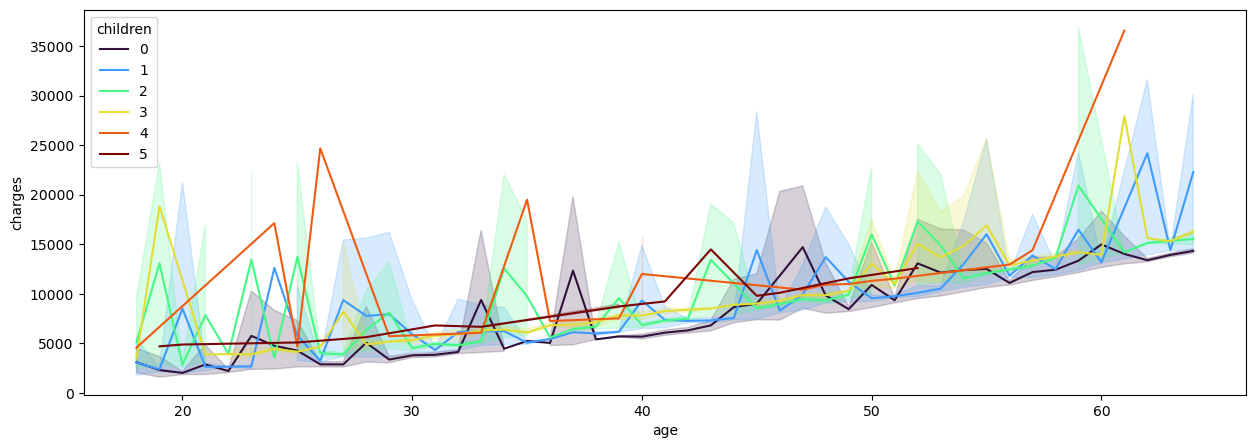

In [255]:
dfns=df[df['smoker']=='no'] ## visualizing effect of children on charges for non-smoker and find that with increase in children charges evenly increases.
plt.figure(figsize=(15,5))  

sns.lineplot(x='age',y='charges',data=dfns,hue='children',palette='turbo')

<Axes: xlabel='bmi', ylabel='charges'>

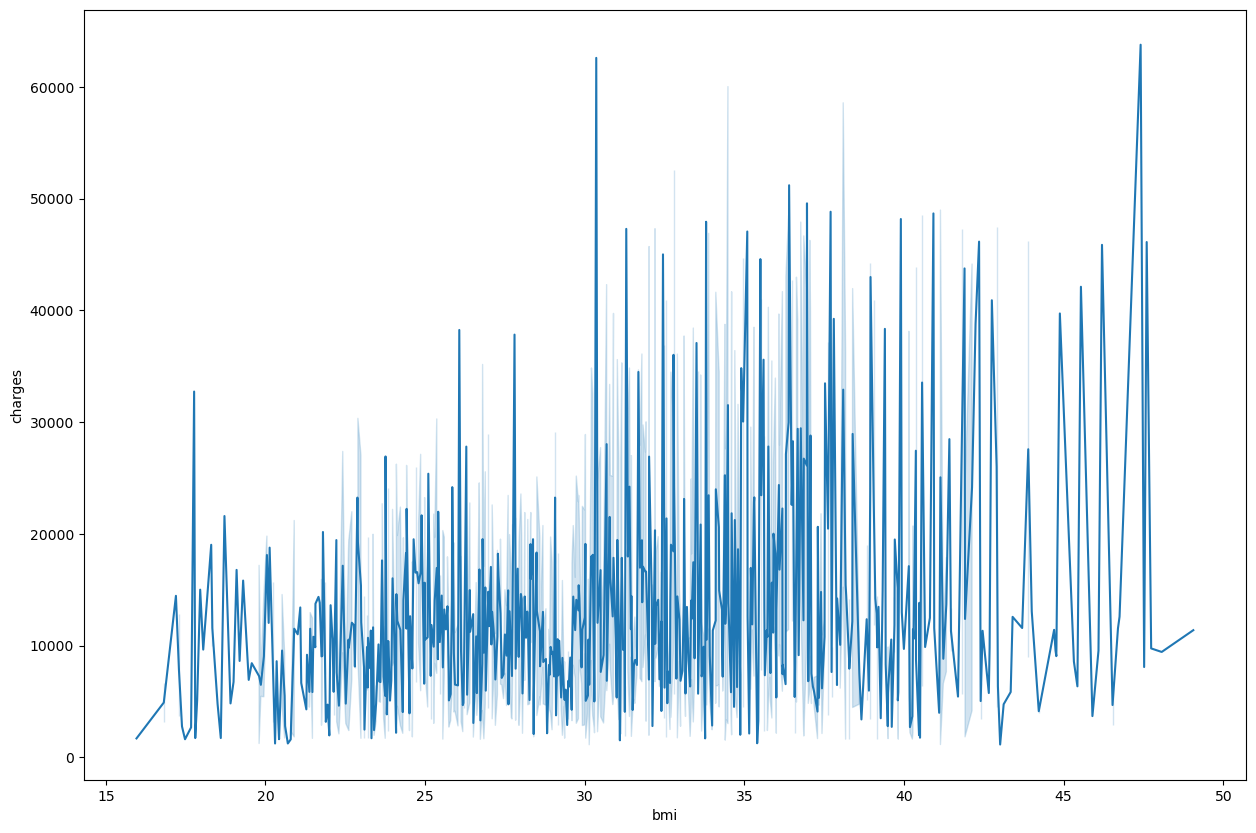

In [256]:
plt.figure(figsize=(15,10))  #Visualising bmi effect on charges as ideal bmi range is between 18.5 to 24.9, the bmi out of the range have high charges.
sns.lineplot(x='bmi',y='charges',data=df)       

<Axes: xlabel='age', ylabel='charges'>

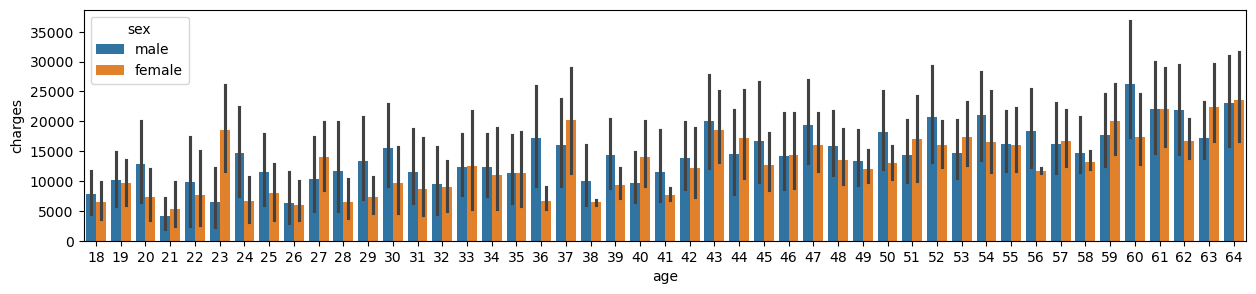

In [257]:
plt.figure(figsize=(15,3)) # Visualising sex effect on charges having same effect of both, hence this column is not decision maker.
sns.barplot(x='age',y='charges',data=df,hue='sex')

In [258]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [259]:
df['sex'].value_counts() # sex coulmn has balanced data

sex
male      672
female    662
Name: count, dtype: int64

In [260]:
df.groupby(['sex'])['bmi'].mean() # sex coulmn has balanced bmi

sex
female    30.377749
male      30.849516
Name: bmi, dtype: float64

In [261]:
df.groupby(['smoker'],as_index=False)['charges'].mean() # shows overview of average charges for smoker and non-smoker.

,smoker,charges
0,no,8453.176614
1,yes,32004.623164


In [262]:
df['sex'].value_counts()

sex
male      672
female    662
Name: count, dtype: int64

In [263]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [264]:
dfsmoker=pd.get_dummies(df['smoker']) # using get dummies method similar as OneHotEncoding to encode smoker columns
dfsmoker

,no,yes
0,False,True
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
1333,True,False
1334,True,False
1335,True,False
1336,True,False


In [265]:
df1=pd.concat([df,dfsmoker],axis=1) # concating encoded column with dataset.
df1

,age,sex,bmi,children,smoker,region,charges,no,yes
0,19,female,27.900,0,yes,southwest,16884.92400,False,True
1,18,male,33.770,1,no,southeast,1725.55230,True,False
2,28,male,33.000,3,no,southeast,4449.46200,True,False
3,33,male,22.705,0,no,northwest,21984.47061,True,False
4,32,male,28.880,0,no,northwest,3866.85520,True,False
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,True,False
1334,18,female,31.920,0,no,northeast,2205.98080,True,False
1335,18,female,36.850,0,no,southeast,1629.83350,True,False
1336,21,female,25.800,0,no,southwest,2007.94500,True,False


In [266]:
df2=df1.drop(['sex','smoker','region','no'],axis=1) # removing unwanted columns for data reduction.
df2

,age,bmi,children,charges,yes
0,19,27.900,0,16884.92400,True
1,18,33.770,1,1725.55230,False
2,28,33.000,3,4449.46200,False
3,33,22.705,0,21984.47061,False
4,32,28.880,0,3866.85520,False
...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False
1334,18,31.920,0,2205.98080,False
1335,18,36.850,0,1629.83350,False
1336,21,25.800,0,2007.94500,False


In [267]:
df2.rename(columns={'yes':'smoker'},inplace=True) #changing encoded column name as smoker
df2

,age,bmi,children,charges,smoker
0,19,27.900,0,16884.92400,True
1,18,33.770,1,1725.55230,False
2,28,33.000,3,4449.46200,False
3,33,22.705,0,21984.47061,False
4,32,28.880,0,3866.85520,False
...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False
1334,18,31.920,0,2205.98080,False
1335,18,36.850,0,1629.83350,False
1336,21,25.800,0,2007.94500,False


## Data cleaning encoding and analysis completed

In [268]:
df2.columns

Index(['age', 'bmi', 'children', 'charges', 'smoker'], dtype='object')

In [269]:
x=df2.drop(['charges'],axis=1) # preparing input data. 
x.head(2)

,age,bmi,children,smoker
0,19,27.90,0,True
1,18,33.77,1,False


In [270]:
y=df2[['charges']] #preparing output data. 
y.head(2)


,charges
0,16884.9240
1,1725.5523


In [271]:
from sklearn.model_selection import train_test_split #imorting train_test_split model 

In [272]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #split into training and testing.

In [273]:
from sklearn.linear_model import LinearRegression # importing libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error

In [274]:
df_lr=LinearRegression() # training model and analyzing performance on the basis of score. 
df_lr.fit(x_train,y_train)

LinearRegression()

In [275]:
df_lr.score(x_test,y_test)

0.8140388513874569

In [276]:
y_pred1=df_lr.predict(x_test)

In [277]:
mean_absolute_error(y_test,y_pred1) #must be minimum



4134.885990768992

In [278]:
root_mean_squared_error(y_test, y_pred1) #must be minimum


5735.621787769051

In [279]:
r2_score(y_test,y_pred1) #must be maximum

0.8140388513874569

In [280]:
df_lr_cv=cross_val_score(df_lr,x,y,cv=5).mean() #applying cross validatio score method.
df_lr_cv

np.float64(0.7464012436459526)

In [281]:
df_rf=RandomForestRegressor()
df_rf.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [282]:
df_rf.score(x_test,y_test)

0.8750684852637004

In [283]:
y_pred2=df_rf.predict(x_test)

In [284]:
mean_absolute_error(y_test,y_pred2)


2662.6317414167297

In [285]:
root_mean_squared_error(y_test, y_pred2)


4701.1639657067835

In [286]:
r2_score(y_test,y_pred2)

0.8750684852637004

In [287]:
df_rf_cv=cross_val_score(df_lr,x,y,cv=5).mean()
df_rf_cv

np.float64(0.7464012436459526)

In [288]:
df_dt=DecisionTreeRegressor()
df_dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [289]:
df_dt.score(x_test,y_test)

0.8033318659261388

In [290]:
y_pred3=df_dt.predict(x_test)

In [291]:
mean_absolute_error(y_test,y_pred3)

2885.429681044944

In [292]:
root_mean_squared_error(y_test, y_pred3)

5898.429521052276

In [293]:
r2_score(y_test,y_pred3)

0.8033318659261388

In [294]:
df_dt_cv=cross_val_score(df_dt,x,y,cv=5).mean()
df_dt_cv

np.float64(0.7095060170632187)

In [295]:

df_gb=GradientBoostingRegressor()
df_gb.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor()

In [296]:
df_gb.score(x_test,y_test)

0.9028006834856562

In [297]:
y_pred4=df_gb.predict(x_test)

In [298]:
mean_absolute_error(y_test,y_pred4)


2406.2746073933595

In [299]:
root_mean_squared_error(y_test, y_pred4)

4146.684576213646

In [300]:
r2_score(y_test,y_pred4)

0.9028006834856562

### GradientBoostingRegressor shows the best score and minimum error

In [301]:
df_gb_cv=cross_val_score(df_gb,x,y,cv=5).mean()
df_gb_cv

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was p

np.float64(0.8536803785035605)

In [302]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Hyperparameter tuning

In [303]:
from sklearn.model_selection import RandomizedSearchCV ## importing RandomizedSearchCV modelXGB=XGBregressor(random_state=42,verbosity=2)

In [304]:
param_grid = {
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.300000012, 0.4, 0.5, 0.6, 0.7], # slow down the learning process
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [50,65,80,100,115,130,150],
              
              }

In [305]:
rcv= RandomizedSearchCV(estimator=df_gb, scoring='f1',param_distributions=param_grid, n_iter=10, cv=5, # assisgning various parameters to create the model
                               verbose=2, random_state=42, n_jobs=-1,return_train_score=False)

In [306]:
rcv.fit(x_train,y_train)##training data on randomsearch cv

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.06, 0.1,
                                                          0.15, 0.2, 0.25,
                                                          0.300000012, 0.4, 0.5,
                                                          0.6, 0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [50, 65, 80, 100, 115,
                                                         130, 150]},
                   random_state=42, scoring='f1', verbose=2)

In [307]:
cv_best_params = rcv.best_params_ ##it will give you best parameters
print(f"Best paramters: {cv_best_params})")##printing  best parameters

Best paramters: {'n_estimators': 80, 'max_depth': 14, 'learning_rate': 0.5})


In [308]:
gbr1=GradientBoostingRegressor(n_estimators=80,max_depth=14,learning_rate=0.5,random_state=5) # inserting best parameters

In [309]:
gbr1.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor(learning_rate=0.5, max_depth=14, n_estimators=80,
                          random_state=5)

In [310]:
gbr1.score(x_test,y_test)

0.8121425458832359

In [311]:
y_pred5=gbr1.predict(x_test)

In [312]:
mean_absolute_error(y_test,y_pred5)


2884.0371990510366

In [313]:
root_mean_squared_error(y_test, y_pred5)


5764.7916008171605

In [314]:
r2_score(y_test,y_pred5)

0.8121425458832359

In [315]:
x_train.columns

Index(['age', 'bmi', 'children', 'smoker'], dtype='object')

## Best score obtained by GradientBoostingRegressor 
### having best score:0.889,minimum mean_absolute_error:2439, minimum root_mean_squared_error:4222, maximum r2_score:0.889

### Below is the prediction model to take input from the user

In [317]:
age=float(input("Enter age"))
bmi=float(input("Enter bmi"))
children=float(input("Enter children"))
smoker=float(input("Enter smoker"))
insurance_cost_prediction=df_gb.predict([[age,bmi,children,smoker]])
print()
print('The insurance cost predicted according to your requirement is', insurance_cost_prediction)

Enter age 19
Enter bmi 33
Enter children 2
Enter smoker 1



The insurance cost predicted according to your requirement is [37029.19489843]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


### The above data includes numerical features such as age, BMI, number of children, and insurance charges, along with categorical features like gender, smoking status, and region.Age showed a steady positive relationship with insurance charges, reflecting increasing medical needs over time. BMI demonstrated a moderate impact, especially at higher values. Smoking status emerged as the most significant factor, with smokers incurring substantially higher costs than non-smokers. The number of children showed a weak positive influence on charges. Gender and regional differences were minimal in determining costs. Correlation analysis confirmed smoking, age, and BMI as the strongest predictors.Data was split into training and testing sets. Multiple regression models were trained and evaluated. Linear regression provided a baseline but showed limited accuracy. Regularized models slightly improved performance but could not capture complexity. Tree-based models performed significantly better. Random Forest classifier achieved good predictive accuracy and low error. Gradient Boosting regressor delivered the best overall results. It achieved the highest R² score and the lowest RMSE among all models tested. Input options are provided to insert values as per the requirement and get the predicted insurance cost.